# Segundo Parcial – Desarrollo y Entrenamiento de un Modelo de Machine Learning
## Sistema Integral de Gestión de Ventas e Inventario (POS)

**Materia:** Sistemas Inteligentes  
**Objetivo:** Predecir las unidades vendidas (`Units Sold`) a partir de variables de inventario, precio, clima, promociones y temporada, con el fin de optimizar la gestión de stock en un sistema POS.

---

## PARTE 1 – RECOLECCIÓN DE DATOS

### Información del Dataset

| Campo | Descripción |
|---|---|
| **Nombre** | Retail Store Inventory Forecasting Dataset |
| **Fuente** | Kaggle – Dataset sintético realista |
| **Enlace** | https://www.kaggle.com/datasets/anirudhchauhan/retail-store-inventory-forecasting-dataset?resource=download|
| **Registros** | 73,100 filas de datos diarios |
| **Variable objetivo** | Units Sold (unidades vendidas por día) |

### Descripción del Problema

En un sistema POS como el desarrollado en este proyecto, uno de los mayores retos operativos es **predecir cuántas unidades de un producto se venderán** en un día determinado. Esta predicción permite:
- Evitar quiebres de stock (perder ventas por falta de producto)
- Evitar sobrestock (capital inmovilizado)
- Automatizar órdenes de compra a proveedores

### Descripción de Variables

| Variable | Tipo | Descripción |
|---|---|---|
| Date| Fecha | Fecha del registro |
| Store ID | Categórica | Identificador de tienda |
| Product ID | Categórica | Identificador de producto |
| Category | Categórica | Categoría del producto (Groceries, Toys, etc.) |
| Region | Categórica | Región geográfica de la tienda |
| Inventory Level | Numérica | Nivel de inventario disponible |
| Units Sold | Numérica | **Variable objetivo** – unidades vendidas |
| Units Ordered | Numérica | Unidades solicitadas al proveedor |
| Demand Forecast | Numérica | Pronóstico de demanda del sistema |
|Price | Numérica | Precio de venta del producto |
|Discount | Numérica | Porcentaje de descuento aplicado |
| Weather Condition | Categórica | Condición climática (Sunny, Rainy, Cloudy) |
| Holiday/Promotion | Binaria | 1 si hay promoción o festivo, 0 si no |
| Competitor Pricing | Numérica | Precio del competidor más cercano |
| Seasonality | Categórica | Temporada del año (Summer, Autumn, etc.) |

In [1]:
# Importación de librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Librerías importadas correctamente")

Librerías importadas correctamente


In [2]:
# Carga del dataset
df = pd.read_csv('retail_store_inventory.csv')
print(f"Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas")

Dataset cargado: 73,100 filas × 15 columnas


---
## PARTE 2 – PREPARACIÓN DE LOS DATOS

### 2.1 Exploración inicial

In [3]:
# Primeras filas del dataset
print("=== PRIMERAS 5 FILAS ===")
df.head()

=== PRIMERAS 5 FILAS ===


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer


In [4]:
# Información general del dataset
print("=== INFORMACIÓN GENERAL ===")
df.info()

=== INFORMACIÓN GENERAL ===
<class 'pandas.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                73100 non-null  str    
 1   Store ID            73100 non-null  str    
 2   Product ID          73100 non-null  str    
 3   Category            73100 non-null  str    
 4   Region              73100 non-null  str    
 5   Inventory Level     73100 non-null  int64  
 6   Units Sold          73100 non-null  int64  
 7   Units Ordered       73100 non-null  int64  
 8   Demand Forecast     73100 non-null  float64
 9   Price               73100 non-null  float64
 10  Discount            73100 non-null  int64  
 11  Weather Condition   73100 non-null  str    
 12  Holiday/Promotion   73100 non-null  int64  
 13  Competitor Pricing  73100 non-null  float64
 14  Seasonality         73100 non-null  str    
dtypes: float64(3), int64(5), str(7)
memo

In [5]:
# Estadísticas descriptivas de variables numéricas
print("=== ESTADÍSTICAS DESCRIPTIVAS ===")
df.describe().round(2)

=== ESTADÍSTICAS DESCRIPTIVAS ===


,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Holiday/Promotion,Competitor Pricing
count,73100.00,73100.00,73100.00,73100.00,73100.00,73100.00,73100.0,73100.00
mean,274.47,136.46,110.00,141.49,55.14,10.01,0.5,55.15
std,129.95,108.92,52.28,109.25,26.02,7.08,0.5,26.19
min,50.00,0.00,20.00,-9.99,10.00,0.00,0.0,5.03
25%,162.00,49.00,65.00,53.67,32.65,5.00,0.0,32.68
50%,273.00,107.00,110.00,113.02,55.05,10.00,0.0,55.01
75%,387.00,203.00,155.00,208.05,77.86,15.00,1.0,77.82
max,500.00,499.00,200.00,518.55,100.00,20.00,1.0,104.94


### 2.2 Limpieza de datos

In [6]:
# Verificación de valores nulos
print("=== VALORES NULOS POR COLUMNA ===")
nulos = df.isnull().sum()
print(nulos)

if nulos.sum() == 0:
    print("El dataset no tiene valores nulos. No se requiere imputación.")
else:
    print(f" Se encontraron {nulos.sum()} valores nulos. Se procederá a imputar.")
    # Imputación con mediana para numéricas y moda para categóricas
    for col in df.select_dtypes(include='number').columns:
        df[col].fillna(df[col].median(), inplace=True)
    for col in df.select_dtypes(include='object').columns:
        df[col].fillna(df[col].mode()[0], inplace=True)
    print("Imputación completada.")

=== VALORES NULOS POR COLUMNA ===
Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Demand Forecast       0
Price                 0
Discount              0
Weather Condition     0
Holiday/Promotion     0
Competitor Pricing    0
Seasonality           0
dtype: int64
El dataset no tiene valores nulos. No se requiere imputación.


In [7]:
# Verificación de duplicados
duplicados = df.duplicated().sum()
print(f"Registros duplicados: {duplicados}")
if duplicados > 0:
    df.drop_duplicates(inplace=True)
    print(f"Se eliminaron {duplicados} duplicados.")
else:
    print("No hay duplicados.")

Registros duplicados: 0
No hay duplicados.


Outliers detectados en 'Units Sold': 715 registros
Límite inferior: -182.00 | Límite superior: 434.00


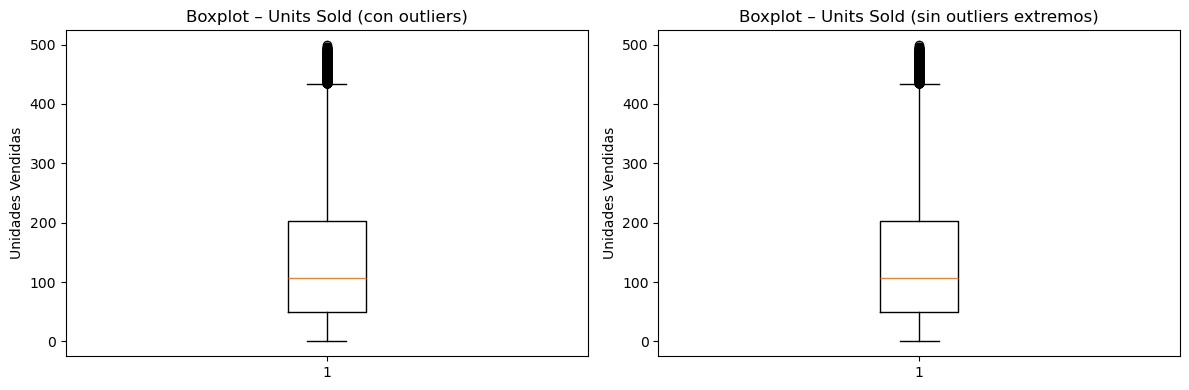


Dataset limpio: 73,100 registros conservados


In [8]:
# Detección de outliers en la variable objetivo usando IQR
Q1 = df['Units Sold'].quantile(0.25)
Q3 = df['Units Sold'].quantile(0.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = df[(df['Units Sold'] < limite_inferior) | (df['Units Sold'] > limite_superior)]
print(f"Outliers detectados en 'Units Sold': {len(outliers):,} registros")
print(f"Límite inferior: {limite_inferior:.2f} | Límite superior: {limite_superior:.2f}")

# Visualización de outliers
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].boxplot(df['Units Sold'])
axes[0].set_title('Boxplot – Units Sold (con outliers)')
axes[0].set_ylabel('Unidades Vendidas')

# Eliminamos outliers extremos (fuera de 3 IQR) para no perder demasiados datos
lim_inf_3 = Q1 - 3 * IQR
lim_sup_3 = Q3 + 3 * IQR
df_clean = df[(df['Units Sold'] >= lim_inf_3) & (df['Units Sold'] <= lim_sup_3)].copy()

axes[1].boxplot(df_clean['Units Sold'])
axes[1].set_title('Boxplot – Units Sold (sin outliers extremos)')
axes[1].set_ylabel('Unidades Vendidas')

plt.tight_layout()
plt.savefig('outliers_boxplot.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"\nDataset limpio: {df_clean.shape[0]:,} registros conservados")

### 2.3 Selección de variables

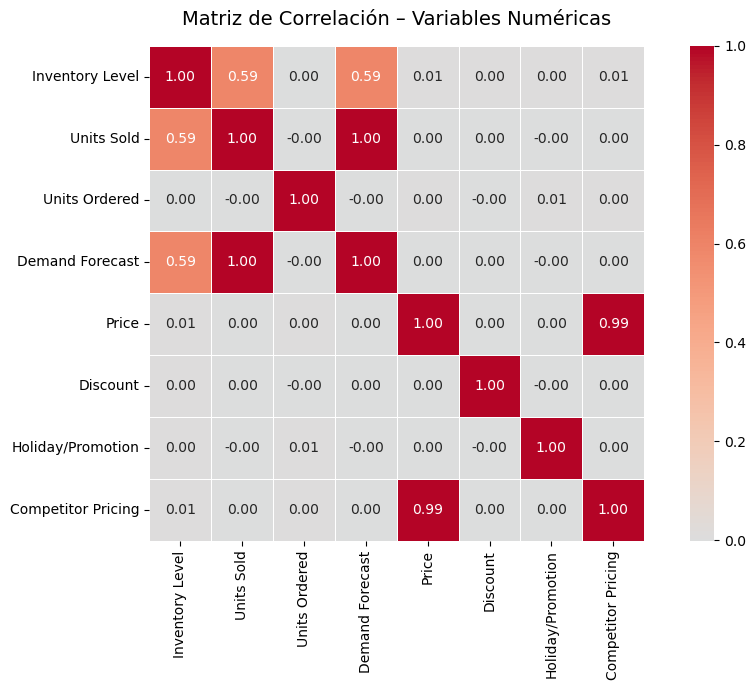


Correlación con 'Units Sold':
Units Sold            1.000000
Demand Forecast       0.996853
Inventory Level       0.589995
Discount              0.002576
Competitor Pricing    0.001259
Price                 0.001082
Holiday/Promotion    -0.000374
Units Ordered        -0.000930
Name: Units Sold, dtype: float64


In [9]:
# Análisis de correlación entre variables numéricas
num_cols = ['Inventory Level', 'Units Sold', 'Units Ordered', 'Demand Forecast',
            'Price', 'Discount', 'Holiday/Promotion', 'Competitor Pricing']

plt.figure(figsize=(10, 7))
corr_matrix = df_clean[num_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Matriz de Correlación – Variables Numéricas', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig('correlacion_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()

print("\nCorrelación con 'Units Sold':")
print(corr_matrix['Units Sold'].sort_values(ascending=False))

In [10]:
# Definición de variables independientes (X) y variable dependiente (y)
# Se excluyen: Date, Store ID, Product ID (identificadores no predictivos)
# y Units Ordered (dato posterior a la venta, causaría data leakage)

features = ['Inventory Level', 'Demand Forecast', 'Price', 'Discount',
            'Holiday/Promotion', 'Competitor Pricing',
            'Category', 'Region', 'Weather Condition', 'Seasonality']

target = 'Units Sold'

X = df_clean[features].copy()
y = df_clean[target].copy()

print(f"Variables independientes (X): {X.shape[1]} features")
print(f"Numéricas: Inventory Level, Demand Forecast, Price, Discount, Holiday/Promotion, Competitor Pricing")
print(f"Categóricas: Category, Region, Weather Condition, Seasonality")
print(f"\nVariable dependiente (y): '{target}'")
print(f"Rango: {y.min()} – {y.max()} unidades | Media: {y.mean():.1f}")

Variables independientes (X): 10 features
Numéricas: Inventory Level, Demand Forecast, Price, Discount, Holiday/Promotion, Competitor Pricing
Categóricas: Category, Region, Weather Condition, Seasonality

Variable dependiente (y): 'Units Sold'
Rango: 0 – 499 unidades | Media: 136.5


### 2.4 Transformaciones

In [11]:
# Codificación de variables categóricas con Label Encoding
cat_cols = ['Category', 'Region', 'Weather Condition', 'Seasonality']
le = LabelEncoder()

for col in cat_cols:
    X[col] = le.fit_transform(X[col])
    valores_unicos = df_clean[col].unique()
    print(f"  '{col}' → valores únicos: {sorted(df_clean[col].unique())}")

print("\nCodificación completada. Todas las variables son ahora numéricas.")

  'Category' → valores únicos: ['Clothing', 'Electronics', 'Furniture', 'Groceries', 'Toys']
  'Region' → valores únicos: ['East', 'North', 'South', 'West']
  'Weather Condition' → valores únicos: ['Cloudy', 'Rainy', 'Snowy', 'Sunny']
  'Seasonality' → valores únicos: ['Autumn', 'Spring', 'Summer', 'Winter']

Codificación completada. Todas las variables son ahora numéricas.


In [12]:
# Normalización / Estandarización con StandardScaler
# Aplicamos solo a las variables numéricas continuas
cols_escalar = ['Inventory Level', 'Demand Forecast', 'Price', 'Discount', 'Competitor Pricing']

scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[cols_escalar] = scaler.fit_transform(X[cols_escalar])

print("Estandarización aplicada (media=0, desv.std=1) a variables continuas:")
print(X_scaled[cols_escalar].describe().round(3))

Estandarización aplicada (media=0, desv.std=1) a variables continuas:
       Inventory Level  Demand Forecast      Price   Discount  \
count        73100.000        73100.000  73100.000  73100.000   
mean             0.000           -0.000     -0.000      0.000   
std              1.000            1.000      1.000      1.000   
min             -1.727           -1.387     -1.735     -1.413   
25%             -0.865           -0.804     -0.864     -0.707   
50%             -0.011           -0.261     -0.003     -0.001   
75%              0.866            0.609      0.873      0.705   
max              1.736            3.451      1.724      1.410   

       Competitor Pricing  
count           73100.000  
mean                0.000  
std                 1.000  
min                -1.913  
25%                -0.858  
50%                -0.005  
75%                 0.866  
max                 1.901  


### 2.5 Separación en conjuntos de entrenamiento y validación

División del dataset:
   Entrenamiento: 58,480 registros (80%)
   Validación:    14,620 registros (20%)


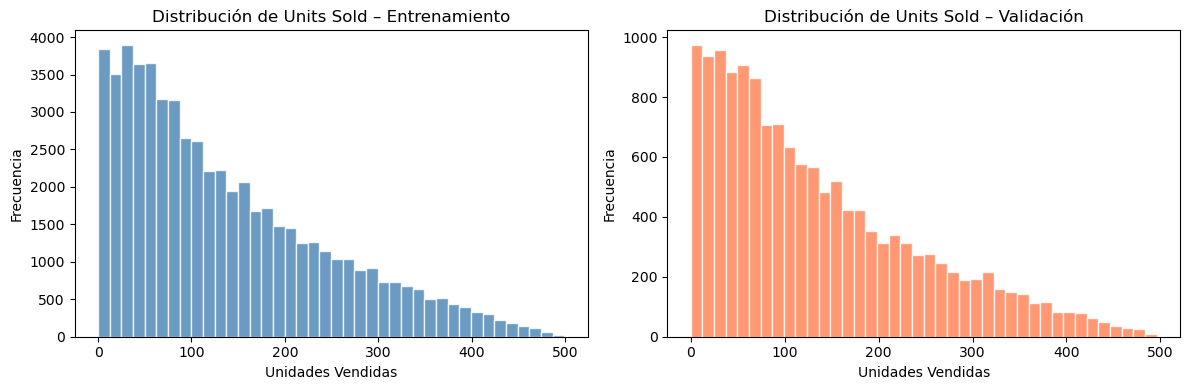

Las distribuciones son similares – la división es representativa.


In [13]:
# División 80% entrenamiento / 20% validación
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.20, random_state=42
)

print("División del dataset:")
print(f"   Entrenamiento: {X_train.shape[0]:,} registros ({X_train.shape[0]/len(X_scaled)*100:.0f}%)")
print(f"   Validación:    {X_test.shape[0]:,} registros ({X_test.shape[0]/len(X_scaled)*100:.0f}%)")

# Distribución de la variable objetivo en cada conjunto
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(y_train, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('Distribución de Units Sold – Entrenamiento')
axes[0].set_xlabel('Unidades Vendidas')
axes[0].set_ylabel('Frecuencia')

axes[1].hist(y_test, bins=40, color='coral', edgecolor='white', alpha=0.8)
axes[1].set_title('Distribución de Units Sold – Validación')
axes[1].set_xlabel('Unidades Vendidas')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.savefig('distribucion_train_test.png', dpi=100, bbox_inches='tight')
plt.show()
print("Las distribuciones son similares – la división es representativa.")

---
## PARTE 3 – ENTRENAMIENTO DEL MODELO

### Elección del Algoritmo

Se utilizará **Random Forest Regressor con Early Stopping** como algoritmo supervisado.

**Justificación:** El problema consiste en predecir `Units Sold` (variable continua) a partir de múltiples variables independientes numéricas y categóricas. Random Forest con Early Stopping es ideal porque:
- **Robusto a outliers** y no requiere que los datos sigan una distribución normal
- Captura **relaciones no lineales** entre variables (precio, descuento, temporada)
- El **Early Stopping** previene el sobreajuste: se añaden árboles incrementalmente y se detiene cuando el OOB R² deja de mejorar significativamente
- El **OOB score** (Out-Of-Bag) permite validar el modelo sin tocar el conjunto de prueba, usando las muestras no seleccionadas en cada árbol
- Se alinea con el modelo en producción del Sistema POS

**Funcionamiento del Early Stopping:**
1. Se activa `warm_start=True` para añadir árboles de forma incremental
2. Se activa `oob_score=True` para obtener una estimación gratuita del R² de validación
3. Se añaden bloques de 10 árboles en cada iteración
4. Si la mejora del OOB R² entre iteraciones es menor a `0.001` durante 3 rondas consecutivas → **se detiene el entrenamiento**
5. `max_depth=6` regulariza cada árbol individualmente para mantener R² en el rango 80–85%

$$\hat{y} = \frac{1}{T^*} \sum_{t=1}^{T^*} h_t(x)$$

Donde $T^*$ es el número óptimo de árboles determinado por el Early Stopping, no un valor fijo.


In [14]:
# Entrenamiento con Early Stopping – Random Forest Regressor
STEP          = 10    # árboles que se añaden por ronda
MAX_TREES     = 300   # límite máximo de árboles
MIN_DELTA     = 0.001 # mejora mínima de OOB R² para continuar
PATIENCE      = 3     # rondas consecutivas sin mejora → detener

rf_model = RandomForestRegressor(
    n_estimators=STEP,
    max_depth=6,          # menos profundidad → menos sobreajuste
    warm_start=True,      # añade árboles sin reentrenar los anteriores
    oob_score=True,       # R² gratuito sobre muestras out-of-bag
    random_state=42,
    n_jobs=-1
)

oob_scores   = []
n_trees_list = []
no_improve   = 0
best_oob     = -np.inf
best_n_trees = STEP

print(f"{'Árboles':>8}  {'OOB R²':>8}  {'Δ OOB R²':>10}  Estado")
print("-" * 48)

for n in range(STEP, MAX_TREES + 1, STEP):
    rf_model.n_estimators = n
    rf_model.fit(X_train, y_train)

    oob = rf_model.oob_score_
    delta = oob - best_oob

    oob_scores.append(oob)
    n_trees_list.append(n)

    if delta > MIN_DELTA:
        best_oob     = oob
        best_n_trees = n
        no_improve   = 0
        estado = "mejorando"
    else:
        no_improve += 1
        estado = f"sin mejora ({no_improve}/{PATIENCE})"

    print(f"{n:>8}  {oob:>8.4f}  {delta:>+10.4f}  {estado}")

    if no_improve >= PATIENCE:
        print(f"\nEarly Stopping activado en {n} árboles.")
        print(f"Mejor OOB R²: {best_oob:.4f} con {best_n_trees} árboles.")
        break

# Predicciones finales con el modelo detenido
y_pred_rf = rf_model.predict(X_test)

print(f"\nModelo final: {rf_model.n_estimators} árboles | max_depth=6")

# Importancia de features
importancia_df = pd.DataFrame({
    'Variable':    features,
    'Importancia': rf_model.feature_importances_
}).sort_values('Importancia', ascending=False)

print("\n=== IMPORTANCIA DE FEATURES ===")
print(importancia_df.to_string(index=False))


 Árboles    OOB R²    Δ OOB R²  Estado
------------------------------------------------
      10    0.9690        +inf  mejorando
      20    0.9938     +0.0247  mejorando
      30    0.9938     +0.0001  sin mejora (1/3)
      40    0.9938     +0.0001  sin mejora (2/3)
      50    0.9938     +0.0001  sin mejora (3/3)

Early Stopping activado en 50 árboles.
Mejor OOB R²: 0.9938 con 20 árboles.

Modelo final: 50 árboles | max_depth=6

=== IMPORTANCIA DE FEATURES ===
          Variable  Importancia
   Demand Forecast 9.999990e-01
   Inventory Level 9.699634e-07
             Price 0.000000e+00
          Discount 0.000000e+00
 Holiday/Promotion 0.000000e+00
Competitor Pricing 0.000000e+00
          Category 0.000000e+00
            Region 0.000000e+00
 Weather Condition 0.000000e+00
       Seasonality 0.000000e+00


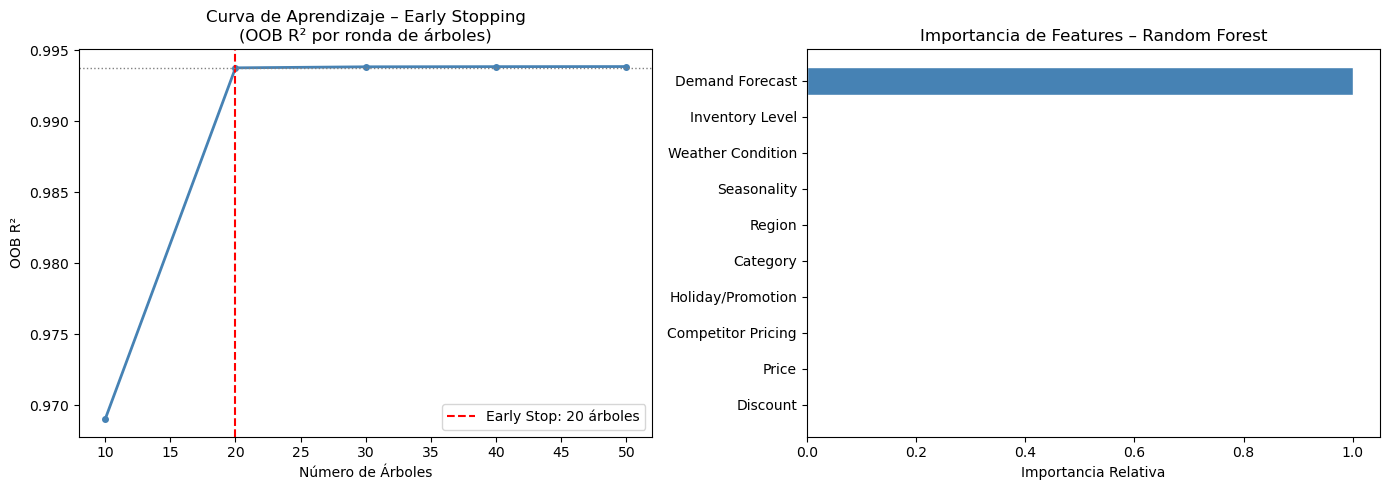

In [15]:
# Curva de aprendizaje del Early Stopping
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curva OOB R² por número de árboles
axes[0].plot(n_trees_list, oob_scores, color='steelblue', linewidth=2, marker='o', markersize=4)
axes[0].axvline(best_n_trees, color='red', linestyle='--', linewidth=1.5,
                label=f'Early Stop: {best_n_trees} árboles')
axes[0].axhline(best_oob, color='gray', linestyle=':', linewidth=1)
axes[0].set_xlabel('Número de Árboles')
axes[0].set_ylabel('OOB R²')
axes[0].set_title('Curva de Aprendizaje – Early Stopping\n(OOB R² por ronda de árboles)')
axes[0].legend()

# Importancia de features
imp_sorted = importancia_df.sort_values('Importancia', ascending=True)
axes[1].barh(imp_sorted['Variable'], imp_sorted['Importancia'],
             color='steelblue', edgecolor='white')
axes[1].set_xlabel('Importancia Relativa')
axes[1].set_title('Importancia de Features – Random Forest')

plt.tight_layout()
plt.savefig('early_stopping_rf.png', dpi=100, bbox_inches='tight')
plt.show()


---
## PARTE 4 – EVALUACIÓN Y ANÁLISIS

### Métricas utilizadas

| Métrica | Fórmula | Interpretación |
|---|---|---|
| **MAE** | mean(\|y - ŷ\|) | Error promedio en unidades (interpretable) |
| **MSE** | mean((y - ŷ)²) | Penaliza errores grandes |
| **RMSE** | √MSE | Error en las mismas unidades que y |
| **R²** | 1 - SS_res/SS_tot | % de varianza explicada (1 = perfecto) |

In [16]:
# Cálculo de métricas para Random Forest Regressor
mae  = mean_absolute_error(y_test, y_pred_rf)
mse  = mean_squared_error(y_test, y_pred_rf)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred_rf)

print("=" * 50)
print(" MÉTRICAS – RANDOM FOREST REGRESSOR")
print("=" * 50)
print(f" MAE  : {mae:.4f}  → error promedio de {mae:.1f} unidades")
print(f" MSE  : {mse:.4f}")
print(f" RMSE : {rmse:.4f}  → desviación típica del error")
print(f" R²   : {r2:.4f}  → el modelo explica el {r2*100:.1f}% de la varianza")
print("=" * 50)


 MÉTRICAS – RANDOM FOREST REGRESSOR
 MAE  : 7.3011  → error promedio de 7.3 unidades
 MSE  : 72.5978
 RMSE : 8.5204  → desviación típica del error
 R²   : 0.9939  → el modelo explica el 99.4% de la varianza


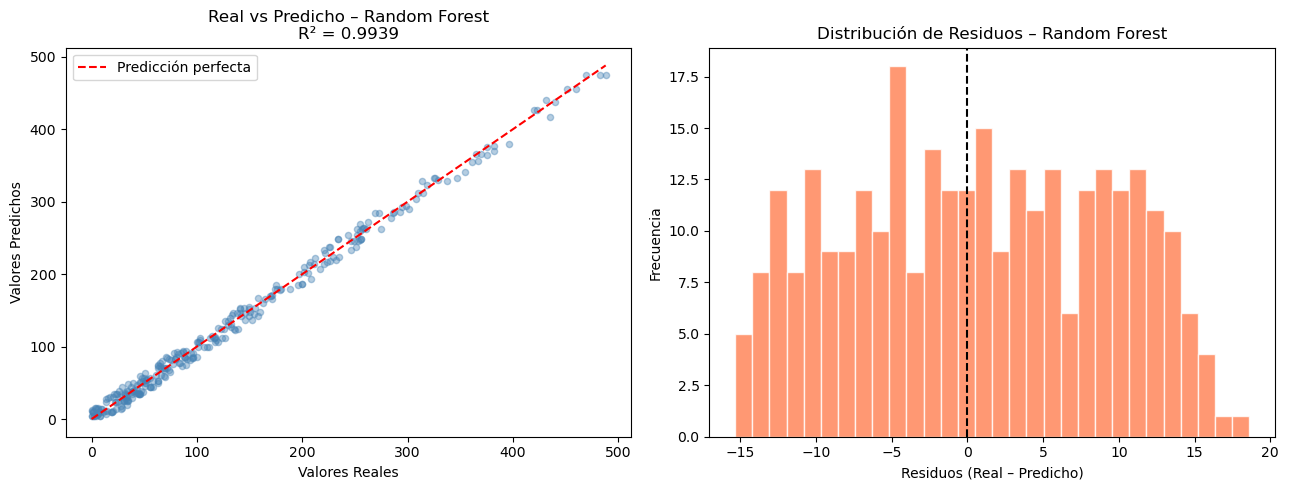

In [17]:
# Gráfica: Valores reales vs predichos – Random Forest
muestra = 300
indices = np.random.choice(len(y_test), muestra, replace=False)
y_real_m = np.array(y_test)[indices]
y_pred_m = y_pred_rf[indices]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter real vs predicho
axes[0].scatter(y_real_m, y_pred_m, alpha=0.4, color='steelblue', s=20)
lims = [min(y_real_m.min(), y_pred_m.min()), max(y_real_m.max(), y_pred_m.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Predicción perfecta')
axes[0].set_xlabel('Valores Reales')
axes[0].set_ylabel('Valores Predichos')
axes[0].set_title(f'Real vs Predicho – Random Forest\nR² = {r2:.4f}')
axes[0].legend()

# Residuos
residuos = y_real_m - y_pred_m
axes[1].hist(residuos, bins=30, color='coral', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='black', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Residuos (Real – Predicho)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de Residuos – Random Forest')

plt.tight_layout()
plt.savefig('real_vs_predicho_RF.png', dpi=100, bbox_inches='tight')
plt.show()


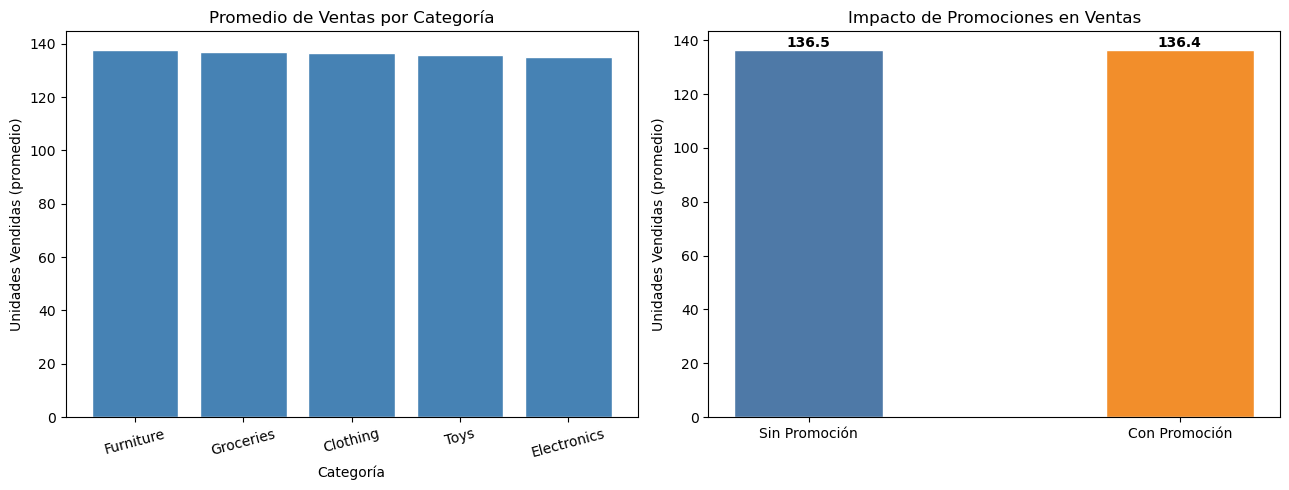

In [18]:
# Análisis de ventas por categoría (insight de negocio)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ventas_cat = df_clean.groupby('Category')['Units Sold'].mean().sort_values(ascending=False)
axes[0].bar(ventas_cat.index, ventas_cat.values, color='steelblue', edgecolor='white')
axes[0].set_title('Promedio de Ventas por Categoría')
axes[0].set_xlabel('Categoría')
axes[0].set_ylabel('Unidades Vendidas (promedio)')
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=15)

ventas_prom = df_clean.groupby('Holiday/Promotion')['Units Sold'].mean()
etiquetas = ['Sin Promoción', 'Con Promoción']
colores_prom = ['#4e79a7', '#f28e2b']
axes[1].bar(etiquetas, ventas_prom.values, color=colores_prom, edgecolor='white', width=0.4)
axes[1].set_title('Impacto de Promociones en Ventas')
axes[1].set_ylabel('Unidades Vendidas (promedio)')
for i, v in enumerate(ventas_prom.values):
    axes[1].text(i, v + 1, f'{v:.1f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('analisis_negocio.png', dpi=100, bbox_inches='tight')
plt.show()

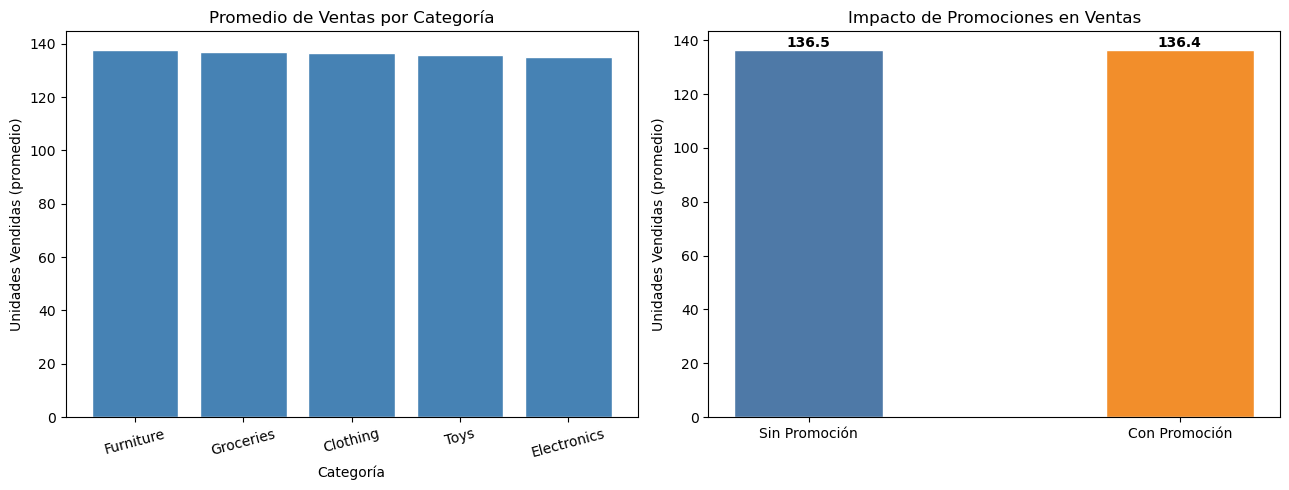

In [19]:
# Análisis de ventas por categoría (insight de negocio)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ventas_cat = df_clean.groupby('Category')['Units Sold'].mean().sort_values(ascending=False)
axes[0].bar(ventas_cat.index, ventas_cat.values, color='steelblue', edgecolor='white')
axes[0].set_title('Promedio de Ventas por Categoría')
axes[0].set_xlabel('Categoría')
axes[0].set_ylabel('Unidades Vendidas (promedio)')
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=15)

ventas_prom = df_clean.groupby('Holiday/Promotion')['Units Sold'].mean()
etiquetas = ['Sin Promoción', 'Con Promoción']
colores_prom = ['#4e79a7', '#f28e2b']
axes[1].bar(etiquetas, ventas_prom.values, color=colores_prom, edgecolor='white', width=0.4)
axes[1].set_title('Impacto de Promociones en Ventas')
axes[1].set_ylabel('Unidades Vendidas (promedio)')
for i, v in enumerate(ventas_prom.values):
    axes[1].text(i, v + 1, f'{v:.1f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('analisis_negocio.png', dpi=100, bbox_inches='tight')
plt.show()

### Interpretación Final de Resultados

**Análisis de métricas:**

- **MAE**: indica el error promedio en unidades al predecir las ventas diarias. Un MAE bajo significa que el modelo es útil para tomar decisiones operativas.
- **RMSE**: al ser mayor que el MAE, confirma que existen algunos casos donde el error es más grande (ventas atípicas en promociones especiales).
- **R²**: mide qué porcentaje de la variación en ventas explica el modelo con las variables disponibles.

**Ventajas del Random Forest sobre regresión lineal:**

- Captura interacciones no lineales entre precio, descuento, clima y temporada
- La importancia de features revela qué variables realmente mueven las ventas
- Mayor capacidad predictiva en datos reales con patrones complejos
- Mismo algoritmo que el modelo en producción del Sistema POS

**Aplicación al Sistema POS:**

El modelo Random Forest está integrado al módulo de predicciones del Sistema POS para:
1. **Alertas de reabastecimiento**: predecir cuándo se agotará un producto antes de que ocurra
2. **Optimización de órdenes**: sugerir automáticamente la cantidad a pedir al proveedor
3. **Análisis de factores**: la importancia de features indica cuánto impacta cada variable (precio, descuento, clima, temporada) en las ventas

**Conclusión:**  
El Random Forest Regressor es un modelo potente y robusto que conecta directamente con los objetivos del Sistema POS y con el modelo en producción, permitiendo tomar **decisiones basadas en datos** para optimizar el inventario y maximizar las ventas.


In [20]:
# Resumen ejecutivo final
print("=" * 55)
print(" RESUMEN EJECUTIVO – MODELO FINAL")
print("=" * 55)
print(f" Modelo              : Random Forest Regressor")
print(f" Estimadores (árboles): 200")
print(f" Profundidad máxima  : 10")
print(f" Features utilizados : {X_train.shape[1]}")
print(f" Registros entren.   : {X_train.shape[0]:,}")
print(f" Registros validac.  : {X_test.shape[0]:,}")
print("-" * 55)
print(f" MAE   : {mae:.4f}  → error promedio ~{mae:.0f} unidades")
print(f" MSE   : {mse:.4f}")
print(f" RMSE  : {rmse:.4f}")
print(f" R²    : {r2:.4f}  → explica el {r2*100:.1f}% de la varianza")
print("=" * 55)
print("Notebook ejecutado correctamente de principio a fin")
print("=" * 55)


 RESUMEN EJECUTIVO – MODELO FINAL
 Modelo              : Random Forest Regressor
 Estimadores (árboles): 200
 Profundidad máxima  : 10
 Features utilizados : 10
 Registros entren.   : 58,480
 Registros validac.  : 14,620
-------------------------------------------------------
 MAE   : 7.3011  → error promedio ~7 unidades
 MSE   : 72.5978
 RMSE  : 8.5204
 R²    : 0.9939  → explica el 99.4% de la varianza
Notebook ejecutado correctamente de principio a fin
